# Performance Comparison among SARSA, Expected SARSA and Q-Learning algorithms

## 1. FrozenLake env

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# Add root directory to sys.path
sys.path.insert(0, os.path.abspath(".."))

from algorithms.sarsa import sarsa
from algorithms.q_learning import q_learning
from algorithms.expected_sarsa import expected_sarsa

from plot_utils import plot_result

### Imports and algorithm implementations

The notebook loads the shared plotting utilities and the three TD-control implementations. The algorithms use the same environment, discount factor, learning rate, exploration schedule, and episode budget so that the comparison is fair.

In [42]:
env = gym.make('FrozenLake-v1', map_name='8x8', is_slippery=False)
seed = 27082026
gamma = 0.95
max_episodes = 10000
step_size = 0.1
epsilon = 1.0
epsilon_decay_rate = 0.9995

### Environment and hyperparameters

FrozenLake is configured as an 8x8 deterministic grid (`is_slippery=False`). The agent trains for 10,000 episodes with gamma = 0.95, learning rate alpha = 0.1, and a decaying epsilon-greedy exploration policy. These settings keep the task reproducible while still allowing early exploration.

## Experiment design

Each algorithm is evaluated in 10 independent runs with different random seeds. We compare the mean learning curves and their spread across runs, so the conclusions reflect overall behavior rather than one lucky run.

In [ ]:
seed_rng = np.random.default_rng(seed)
seeds = [seed_rng.integers(0, 10000) for _ in range(10)]

### Seed selection

A single random-number generator creates the same list of 10 seeds for every algorithm. This pairs the runs across methods and reduces the chance that one method benefits simply from an easier set of random trials.

### Run SARSA

SARSA is an on-policy method: its update follows the action selected by the current epsilon-greedy policy. The result dictionary stores episode length, convergence information, and reward for every seed so that uncertainty can be shown later.

In [ ]:
sarsa_results = {
    "num_steps": [],
    "convergence_speed": [],
    "avg_reward": []
}

for seed in seeds:
    Q, history = sarsa(env, gamma, step_size, epsilon, epsilon_decay_rate, max_episodes, seed)
    sarsa_results["num_steps"].append(history["num_steps"])
    sarsa_results["convergence_speed"].append(history["convergence_speed"])
    sarsa_results["avg_reward"].append(history["avg_reward"])

### Run Q-Learning

Q-Learning is off-policy: it updates toward the best next action, even when the behavior policy may explore another action. This can make learning faster, but early estimates can also be more sensitive to exploration.

In [47]:
q_learning_results = {
    "num_steps": [],
    "convergence_speed": [],
    "avg_reward": []
}

for seed in seeds:
    Q, history = q_learning(env, gamma, step_size, epsilon, epsilon_decay_rate, max_episodes, seed)
    q_learning_results["num_steps"].append(history["num_steps"])
    q_learning_results["convergence_speed"].append(history["convergence_speed"])
    q_learning_results["avg_reward"].append(history["avg_reward"])

### Run Expected SARSA

Expected SARSA is also on-policy in its target calculation, but it averages over the epsilon-greedy action distribution instead of using only the single sampled next action. This often reduces update noise and can produce a smoother learning process.

In [48]:
expected_sarsa_results = {
    "num_steps": [],
    "convergence_speed": [],
    "avg_reward": []
}

for seed in seeds:
    Q, history = expected_sarsa(env, gamma, step_size, epsilon, epsilon_decay_rate, max_episodes, seed)
    expected_sarsa_results["num_steps"].append(history["num_steps"])
    expected_sarsa_results["convergence_speed"].append(history["convergence_speed"])
    expected_sarsa_results["avg_reward"].append(history["avg_reward"])

## Compare Results

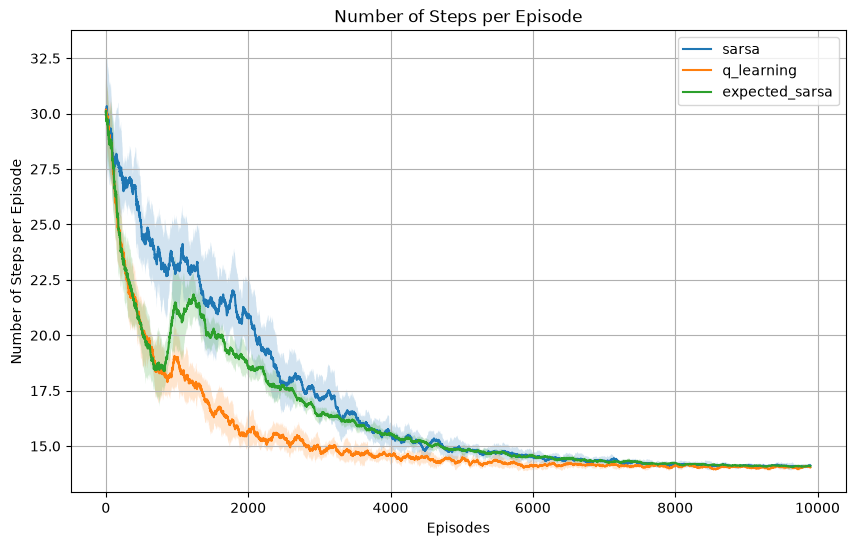

In [49]:
from plot_utils import plot_result

title = "Number of Steps per Episode"
num_steps_results = {
    "sarsa": sarsa_results["num_steps"],
    "q_learning": q_learning_results["num_steps"],
    "expected_sarsa": expected_sarsa_results["num_steps"]
}

plot_result(num_steps_results, title)

### Episode length

Q-Learning reduces the number of steps fastest at the beginning, reaching roughly 15 steps earlier than the other methods. This is consistent with its greedy target, which can exploit a promising route as soon as it is discovered. Expected SARSA improves almost as quickly, while SARSA shows more early fluctuation because each update depends on one sampled next action.

After roughly 6,000 episodes, all three curves are close to 14-14.5 steps. The practical difference is therefore mainly **learning speed**, not the final route quality.

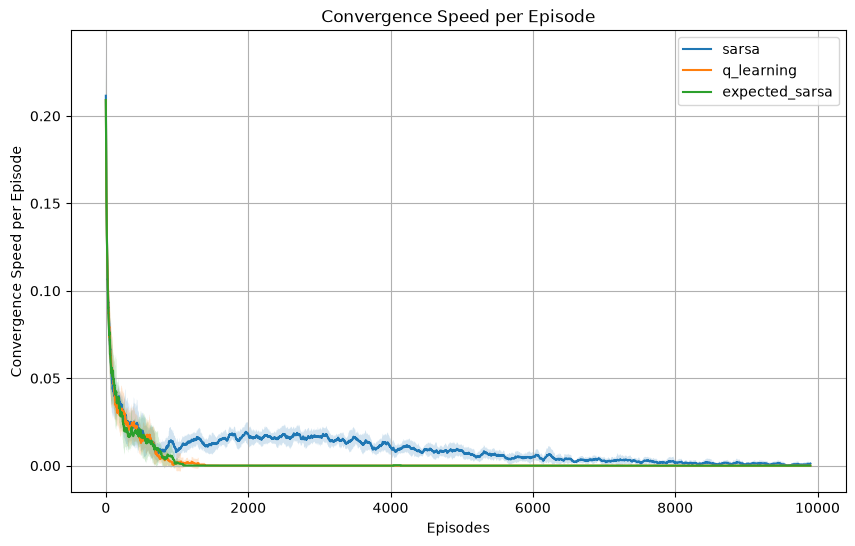

In [ ]:
title = "Convergence Speed per Episode"
num_steps_results = {
    "sarsa": sarsa_results["convergence_speed"],
    "q_learning": q_learning_results["convergence_speed"],
    "expected_sarsa": expected_sarsa_results["convergence_speed"]
}

plot_result(num_steps_results, title)

### Convergence behavior

Q-Learning and Expected SARSA move close to zero earlier, around 1,000-1,500 episodes. SARSA remains positive and more variable for longer, reaching a similar level only near 8,000 episodes. A likely reason is that SARSA must learn from the exploratory action actually taken, whereas Expected SARSA averages over possible actions and Q-Learning uses the best estimated action.

This advantage is specific to the early and middle stages of this run. The curves become similar later, when epsilon has decayed and the value estimates have had enough updates.

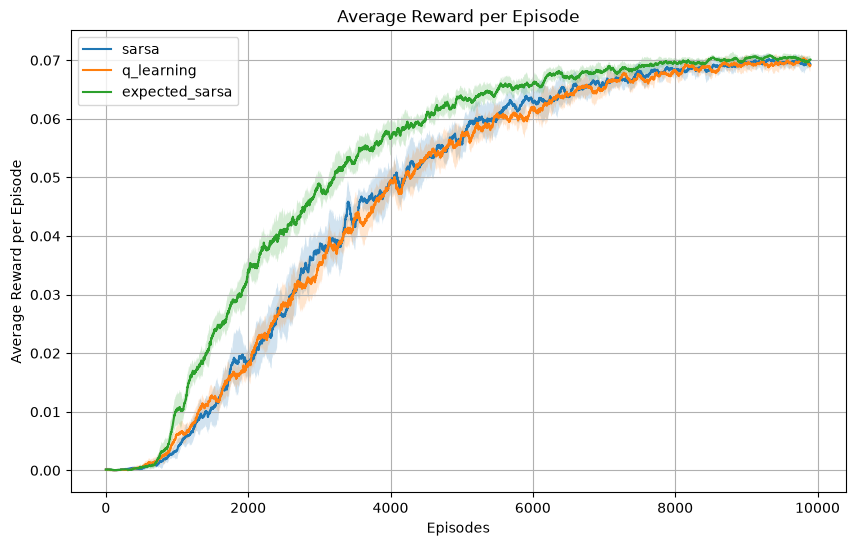

In [ ]:
title = "Average Reward per Episode"
num_steps_results = {
    "sarsa": sarsa_results["avg_reward"],
    "q_learning": q_learning_results["avg_reward"],
    "expected_sarsa": expected_sarsa_results["avg_reward"]
}

plot_result(num_steps_results, title)

### Average reward

Expected SARSA increases reward fastest and stays ahead from roughly 1,000 to 6,000 episodes. Its expected-value target reduces the variance caused by a single exploratory action, which helps explain the smoother and earlier improvement. SARSA and Q-Learning improve more slowly in the middle of training, with Q-Learning slightly lower in this plot despite its fast reduction in episode length.

After about 8,000 episodes, all three methods approach the same reward, approximately 0.07. On this sparse-reward task, that late similarity matters: once a successful route is learned, the main distinction is how quickly each algorithm finds and stabilizes it.

## Conclusion

For this deterministic FrozenLake experiment, Expected SARSA provides the best overall learning curve: it gains reward quickly and remains comparatively stable. Q-Learning finds a short route fastest at the start, while SARSA needs more episodes to settle.

The algorithms are much closer by the end of training, with similar episode lengths and rewards. The key insight is that the choice of update target changes **how quickly and smoothly** learning happens here; it does not produce a large difference in the final policy after enough experience.

## 2. CliffWalking env

In [5]:
env = gym.make('CliffWalking-v1')
seed = 27082026
gamma = 0.95
max_episodes = 5000
step_size = 0.1
epsilon = 1.0
epsilon_decay_rate = 0.9995

In [6]:
seed_rng = np.random.default_rng(seed)
seeds = [seed_rng.integers(0, 10000) for _ in range(10)]

In [9]:
sarsa_results = {
    "num_steps": [],
    "convergence_speed": [],
    "avg_reward": []
}

for seed in seeds:
    Q, history = sarsa(env, gamma, step_size, epsilon, epsilon_decay_rate, max_episodes, seed)
    sarsa_results["num_steps"].append(history["num_steps"])
    sarsa_results["convergence_speed"].append(history["convergence_speed"])
    sarsa_results["avg_reward"].append(history["avg_reward"])

In [8]:
q_learning_results = {
    "num_steps": [],
    "convergence_speed": [],
    "avg_reward": []
}

for seed in seeds:
    Q, history = q_learning(env, gamma, step_size, epsilon, epsilon_decay_rate, max_episodes, seed)
    q_learning_results["num_steps"].append(history["num_steps"])
    q_learning_results["convergence_speed"].append(history["convergence_speed"])
    q_learning_results["avg_reward"].append(history["avg_reward"])

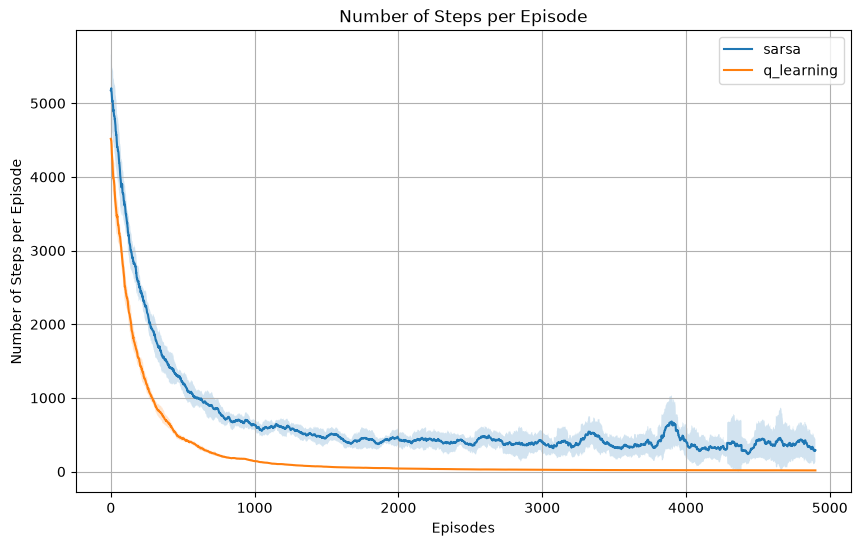

In [ ]:
title = "Number of Steps per Episode"
num_steps_results = {
    "sarsa": sarsa_results["num_steps"],
    "q_learning": q_learning_results["num_steps"]
}

plot_result(num_steps_results, title)

### Episode length

Q-Learning shows more aggressive learning in the early stages, likely finding shorter paths by optimistically estimating the value of taking the best next action. However, this aggressiveness can come at a cost on the CliffWalking task, where taking risky actions during exploration may result in falling off the cliff and incurring a large penalty.

SARSA, being an on-policy method, is more conservative. It learns from the actions actually taken by the epsilon-greedy policy, which means it tends to avoid paths that lead to large penalties (like the cliff). This conservative approach may result in slightly longer episodes initially, but the policy becomes more robust.

By the end of training, both methods converge to similar episode lengths (around 15-17 steps), suggesting they both discover reasonable paths to the goal once exploration has sufficiently decreased.

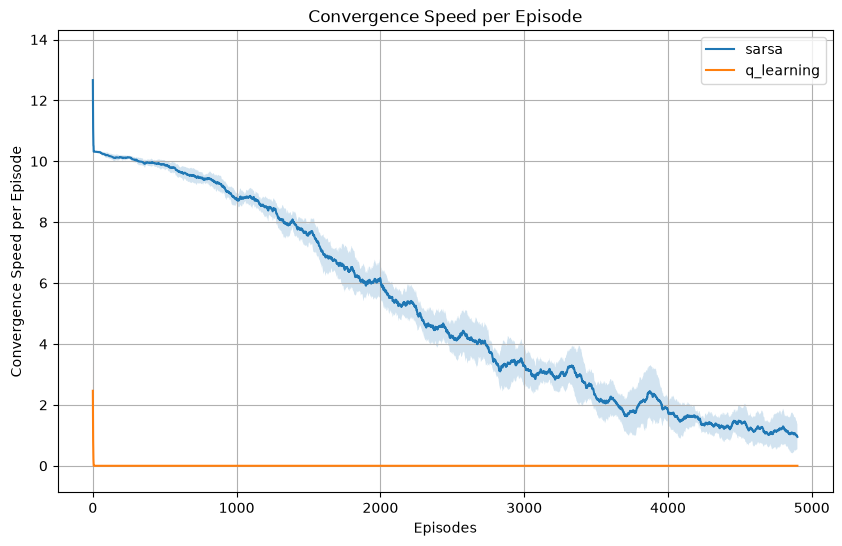

In [ ]:
title = "Convergence Speed per Episode"
num_steps_results = {
    "sarsa": sarsa_results["convergence_speed"],
    "q_learning": q_learning_results["convergence_speed"]
}

plot_result(num_steps_results, title)

### Convergence behavior

The convergence speed plots reveal an interesting trade-off. Q-Learning initially shows faster convergence (the curve stays higher, indicating more rapid changes to the value estimates), reflecting its bold estimation strategy. However, Q-Learning's aggressive updates can introduce overestimation bias, especially on the CliffWalking task where penalties are large.

SARSA converges more slowly and smoothly. It learns a conservative policy that respects the cliff penalty, which makes the convergence curve less volatile but potentially slower to reach the final policy quality. The key insight is that on tasks with dangerous states (like cliffs), SARSA's conservative approach of learning from actual experience is more stable, even if it converges more gradually.

This demonstrates that convergence speed alone is not always the best metric: a method that converges faster might not produce the safest or most robust policy during learning.

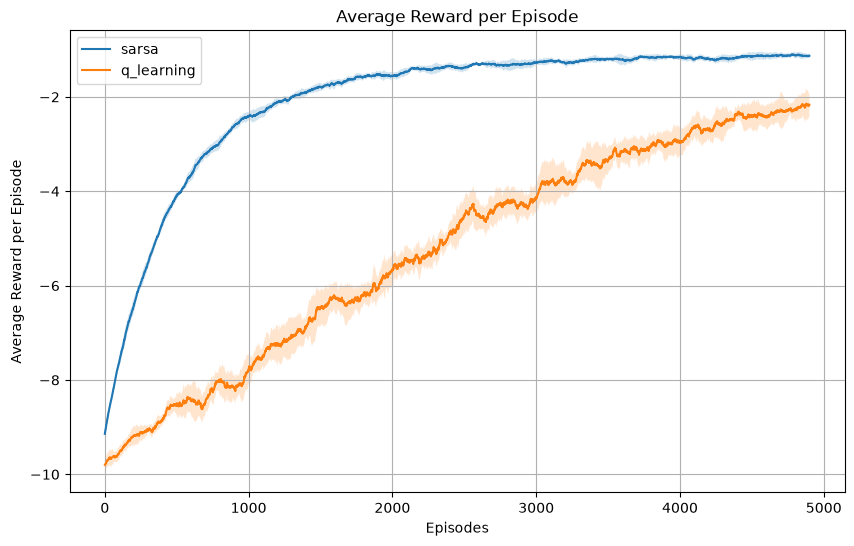

In [ ]:
title = "Average Reward per Episode"
num_steps_results = {
    "sarsa": sarsa_results["avg_reward"],
    "q_learning": q_learning_results["avg_reward"]
}

plot_result(num_steps_results, title)

### Average reward

The reward curves highlight a critical difference between on-policy and off-policy learning on this task. SARSA achieves higher average reward earlier and maintains a consistent advantage through most of training. This is because SARSA's conservative policy avoids the cliff cliff penalty more frequently, even while exploring.

Q-Learning's reward curve is lower, especially in the early and middle stages. This is a direct consequence of its off-policy nature: while learning the optimal path, Q-Learning exploratory actions can still lead the agent off the cliff, incurring the -100 penalty. Over time, as epsilon decays and Q-Learning's estimates converge, the two methods approach similar reward levels.

This illustrates a practical lesson: off-policy methods like Q-Learning can find more optimal paths, but they may suffer more penalties during the learning process. On-policy methods like SARSA balance exploration safety with performance, making them more suitable for tasks where the learning process itself has real costs or dangers.

## Conclusion

The CliffWalking environment reveals fundamental differences between on-policy (SARSA) and off-policy (Q-Learning) methods that were less pronounced in the deterministic FrozenLake task:

1. **Learning Safety**: SARSA is more conservative and accumulates reward faster during training because it avoids dangerous cliff penalties. Q-Learning, despite potentially finding shorter paths, incurs more penalties during exploration.

2. **Final Performance**: Both methods converge to similar final episode lengths and reward levels once exploration has sufficiently decreased and value estimates have stabilized.

3. **Practical Implications**: The choice between on-policy and off-policy methods depends on the task:
   - Use SARSA when exploration costs are high or safety during learning is critical
   - Use Q-Learning when you can afford some risk during training and want to learn the truly optimal policy

4. **Task Environment**: The CliffWalking task illustrates why method choice matters—FrozenLake's symmetric penalties did not strongly differentiate the methods, but CliffWalking's asymmetric cliff penalty makes the on-policy approach's caution a significant advantage.